In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np

import matplotlib
import matplotlib.animation as animation
import matplotlib.pyplot as plt
from IPython.display import HTML
import PIL.Image

from dm_control import mjcf
from dm_control import viewer

from swarmbots.unit import Unit
from swarmbots.rendering import display_video

In [2]:
RENDER_WIDTH = 640
RENDER_HEIGHT = 480

In [105]:
env = mjcf.RootElement()

getattr(env.visual, 'global').offwidth = RENDER_WIDTH
getattr(env.visual, 'global').offheight = RENDER_HEIGHT

chequered = env.asset.add('texture', type='2d', builtin='checker', width=300,
                            height=300, rgb1=[.2, .3, .4], rgb2=[.3, .4, .5])
grid = env.asset.add('material', name='grid', texture=chequered,
                       texrepeat=[5, 5], reflectance=.2)
env.worldbody.add('geom', type='plane', size=[2, 2, .1], material=grid)

for x in [-2, 2]:
  env.worldbody.add('light', pos=[x, -1, 3], dir=[-x, 1, -2])

unit1 = Unit(0.1, 0.2, 0.025, np.pi/2)

spawn_site = env.worldbody.add('site', pos=[0, 0, 2.11], euler=[0, np.pi, 0])#, zaxis=[-np.sqrt(2/9), np.sqrt(2/3), -1/3])#euler=[0, np.pi, np.pi/2])
spawn_site.attach(unit1.model).add('freejoint')
# env.to_xml_string()

unit2 = Unit(0.1, 0.2, 0.025, np.pi/2)
# 
spawn_site = env.worldbody.add('site', pos=[0, 0, 1.5], euler=[0, 0, 0]) #, zaxis=[-np.sqrt(2/9), np.sqrt(2/3), -1/3])#euler=[0, np.pi, np.pi/2])
spawn_site.attach(unit2.model).add('freejoint')

# print(env.worldbody.find_all('body'))

env.equality.add(
    'weld', 
    body1=f'unnamed_model/unnamed_model/{unit1.name}-leg0-foot', 
    body2=f'unnamed_model_1/unnamed_model/{unit2.name}-leg0-foot',
    torquescale=10000
)

# env.to_xml_string()

for geom in env.worldbody.find_all('geom'):
    if False and np.isclose(geom.size[0], 0.0275):
        print(geom.parent.to_xml_string())

[1]


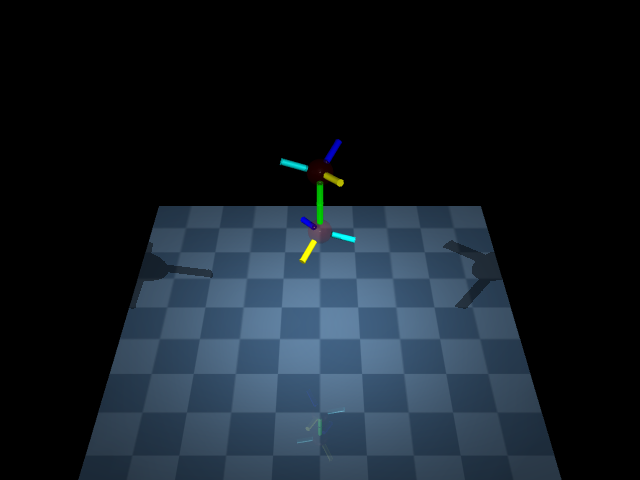

In [106]:
physics = mjcf.Physics.from_mjcf_model(env)
print(physics.data.eq_active)
PIL.Image.fromarray(physics.render(width=RENDER_WIDTH, height=RENDER_HEIGHT))


In [107]:
duration = 10   # (Seconds)
framerate = 30  # (Hz)
video = []
 
last_switch = 0

# Simulate, saving video frames and torso locations.
physics.reset()
while physics.data.time < duration:
    physics.step()

    # Save video frames.
    if len(video) < physics.data.time * framerate:
        pixels = physics.render(width=RENDER_WIDTH, height=RENDER_HEIGHT)
        video.append(pixels.copy())

    # if (physics.data.time - last_switch) > 0.5:
    #   last_switch = physics.data.time
    #   for i in range(4):
    #       physics.data.eq_active[i] = 1 - physics.data.eq_active[i]
    #   print(last_switch)
    
    # if physics.data.time > 3:
    #     physics.data.eq_active[0] = 0
    
    # if physics.data.time > 3.2:
    #     physics.data.eq_active[0] = 1
    
 

display_video(video, framerate)